In [2]:
#Ford Car Price Prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df= pd.read_csv("train.csv")

In [3]:
#Data Loading 
df

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Grand C-MAX,2015,Manual,58199,Diesel,30,64.2,1.5,9499
1,Grand C-MAX,2011,Manual,73780,Petrol,200,40.9,1.6,5485
2,Fiesta,2016,Manual,17050,Petrol,125,54.3,1.2,8600
3,Focus,2018,Manual,19653,Petrol,145,41.5,2.0,17989
4,Fiesta,2016,Manual,32268,Petrol,0,65.7,1.0,8105
...,...,...,...,...,...,...,...,...,...
14367,EcoSport,2018,Manual,9600,Petrol,145,54.3,1.0,14899
14368,Focus,2018,Manual,13938,Petrol,145,41.5,2.0,18495
14369,Focus,2018,Manual,15654,Diesel,145,74.3,1.5,11950
14370,Kuga,2017,Semi-Auto,26663,Diesel,145,54.3,2.0,15998


In [4]:
df.shape

(14372, 9)

In [5]:
df.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize', 'price'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14372 entries, 0 to 14371
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         14372 non-null  str    
 1   year          14372 non-null  int64  
 2   transmission  14372 non-null  str    
 3   mileage       14372 non-null  int64  
 4   fuelType      14372 non-null  str    
 5   tax           14372 non-null  int64  
 6   mpg           14372 non-null  float64
 7   engineSize    14372 non-null  float64
 8   price         14372 non-null  int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [7]:
df.describe()

,year,mileage,tax,mpg,engineSize,price
count,14372.000000,14372.000000,14372.000000,14372.000000,14372.000000,14372.000000
mean,2016.875870,23307.741024,113.334400,57.948761,1.350960,12296.780267
std,2.032725,19404.578773,62.176952,10.172652,0.437659,4742.987542
min,1996.000000,1.000000,0.000000,20.800000,0.000000,675.000000
25%,2016.000000,9959.250000,30.000000,52.300000,1.000000,8999.000000
50%,2017.000000,18256.000000,145.000000,58.900000,1.200000,11295.000000
75%,2018.000000,31000.000000,145.000000,65.700000,1.500000,15299.000000
max,2060.000000,174000.000000,580.000000,201.800000,5.000000,54995.000000


In [8]:
#Data cleaning
# Checking if any null data is there
df.isnull()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
14367,False,False,False,False,False,False,False,False,False
14368,False,False,False,False,False,False,False,False,False
14369,False,False,False,False,False,False,False,False,False
14370,False,False,False,False,False,False,False,False,False


In [9]:
# Calculating the total number of Null Data (If any)
df.isnull().sum()

model           0
year            0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
price           0
dtype: int64

In [10]:
## Calculating the total number of Duplicate Data (If any)
df.duplicated().sum()

np.int64(102)

In [11]:
# Finding all the rows having duplicate data
df[df.duplicated()]


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
877,Kuga,2017,Semi-Auto,18066,Diesel,145,54.3,2.0,17595
2032,Fiesta,2019,Manual,151,Petrol,145,48.7,1.1,13130
2480,Focus,2019,Manual,6200,Petrol,145,49.6,1.0,18975
2752,Focus,2016,Manual,32113,Diesel,0,74.3,1.5,9499
3050,B-MAX,2017,Manual,32442,Petrol,145,55.4,1.0,9495
...,...,...,...,...,...,...,...,...,...
14248,EcoSport,2019,Manual,4357,Petrol,145,53.3,1.0,15995
14311,Focus,2018,Manual,14563,Diesel,145,80.7,1.5,13899
14320,Ka+,2019,Manual,5,Petrol,145,47.9,1.2,10500
14334,Focus,2018,Manual,15919,Petrol,145,57.7,1.0,13491


In [12]:
#Finding details of one of the duplicate data
df.loc[877]

model                Kuga
year                 2017
transmission    Semi-Auto
mileage             18066
fuelType           Diesel
tax                   145
mpg                  54.3
engineSize            2.0
price               17595
Name: 877, dtype: object

In [13]:
#Cross checking the duplicate values to be guranteed
df[df.eq(df.loc[877]).all(axis=1)]

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
280,Kuga,2017,Semi-Auto,18066,Diesel,145,54.3,2.0,17595
877,Kuga,2017,Semi-Auto,18066,Diesel,145,54.3,2.0,17595


In [14]:
# After confirmation, removing all duplicate data
df = df.drop_duplicates()

In [15]:
# Checking whether all duplicate data are removed 
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(14270, 9)

In [17]:
# Exploratory Data Analysis
for col in df.select_dtypes(include="object"):
    print("\n", col)
    print(df[col].value_counts())


 model
model
 Fiesta                   5186
 Focus                    3696
 Kuga                     1746
 EcoSport                  929
 C-MAX                     454
 Ka+                       415
 Mondeo                    415
 B-MAX                     266
 S-MAX                     235
 Grand C-MAX               198
 Galaxy                    179
 Edge                      161
 KA                        145
 Puma                       57
 Tourneo Custom             52
 Mustang                    49
 Grand Tourneo Connect      43
 Tourneo Connect            27
 Fusion                     12
 Streetka                    1
 Ranger                      1
 Transit Tourneo             1
 Escort                      1
Focus                        1
Name: count, dtype: int64

 transmission
transmission
Manual       12332
Automatic     1078
Semi-Auto      860
Name: count, dtype: int64

 fuelType
fuelType
Petrol      9679
Diesel      4574
Hybrid        15
Electric       1
Other          1


C:\Users\user\AppData\Local\Temp\ipykernel_5156\3057380300.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [18]:
(df['engineSize']==0).sum()

np.int64(42)

In [19]:
### DATASET OVERVIEW 

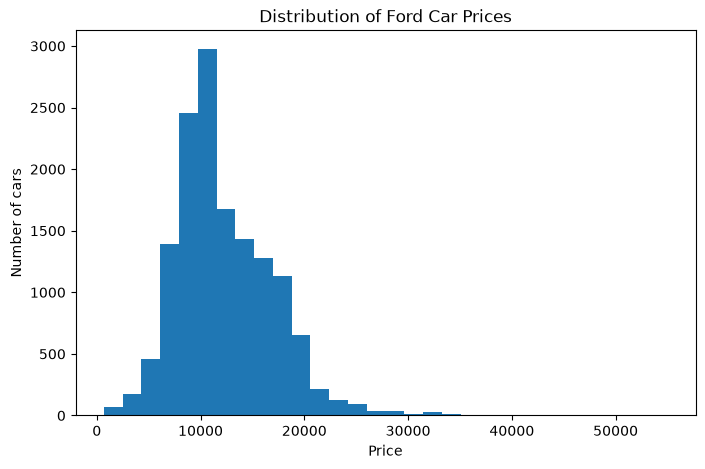

In [20]:
#DISTRIBUTION OF CAR PRICES
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30)
plt.xlabel('Price')
plt.ylabel('Number of cars')
plt.title('Distribution of Ford Car Prices')
plt.show()

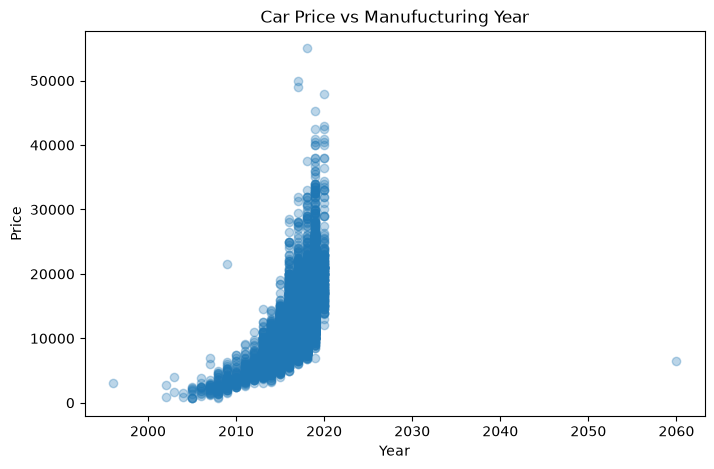

In [21]:
#Relationship between year and price
plt.figure(figsize=(8,5))
plt.scatter(df['year'],df['price'], alpha=0.3)
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Car Price vs Manufucturing Year')
plt.show()

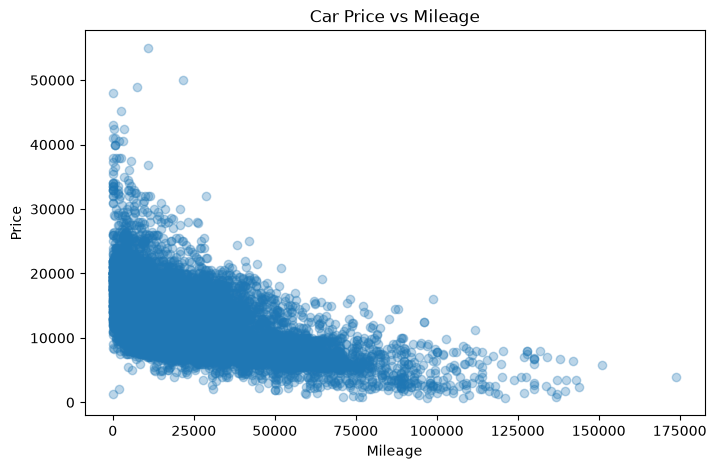

In [22]:
#Relationship between mileage and price
plt.figure(figsize=(8,5))
plt.scatter(df['mileage'],df['price'], alpha=0.3)
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Car Price vs Mileage')
plt.show()

In [23]:
model_price=df.groupby('model')['price'].mean().sort_values()
model_price

model
 Streetka                  1850.000000
 Fusion                    2413.583333
 Escort                    3000.000000
 KA                        5101.262069
 B-MAX                     8251.827068
Focus                      8299.000000
 Ka+                       8727.838554
 C-MAX                     9935.579295
 Fiesta                   10191.202661
 Grand C-MAX              10910.888889
 Mondeo                   12171.874699
 Transit Tourneo          12450.000000
 EcoSport                 12468.241119
 Focus                    13186.521374
 Tourneo Connect          14333.814815
 Ranger                   14495.000000
 Grand Tourneo Connect    15188.302326
 Kuga                     15862.781787
 S-MAX                    17572.314894
 Galaxy                   17767.050279
 Tourneo Custom           21000.250000
 Puma                     21418.684211
 Edge                     23085.484472
 Mustang                  34624.755102
Name: price, dtype: float64

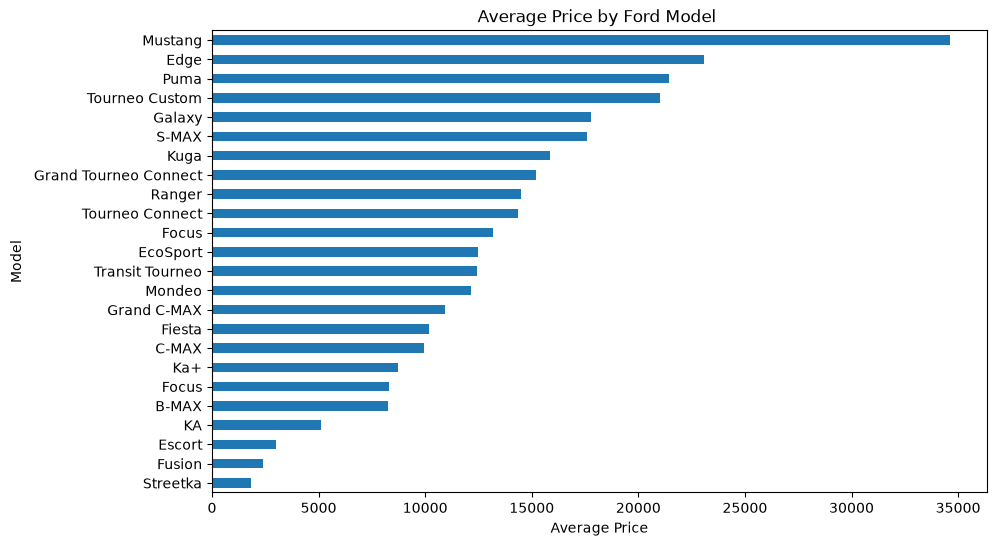

In [24]:
#Average price by each ford model
plt.figure(figsize=(10,6))
model_price.plot(kind='barh')
plt.xlabel('Average Price')
plt.ylabel('Model')
plt.title('Average Price by Ford Model ')
plt.show()

In [25]:
df.groupby('transmission')['price'].mean().sort_values()

transmission
Manual       11793.825576
Semi-Auto    14907.076744
Automatic    15798.892393
Name: price, dtype: float64

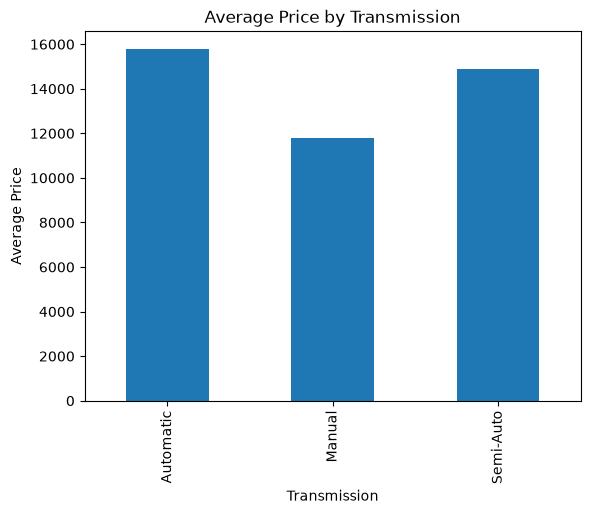

In [26]:
# Average price by transmission
df.groupby('transmission')['price'].mean().plot(kind='bar')
plt.xlabel('Transmission')
plt.ylabel('Average Price')
plt.title('Average Price by Transmission')
plt.show()

In [27]:
df.groupby('fuelType')['price'].mean().sort_values()

fuelType
Petrol      11614.477632
Diesel      13661.081548
Other       13800.000000
Electric    15500.000000
Hybrid      24075.533333
Name: price, dtype: float64

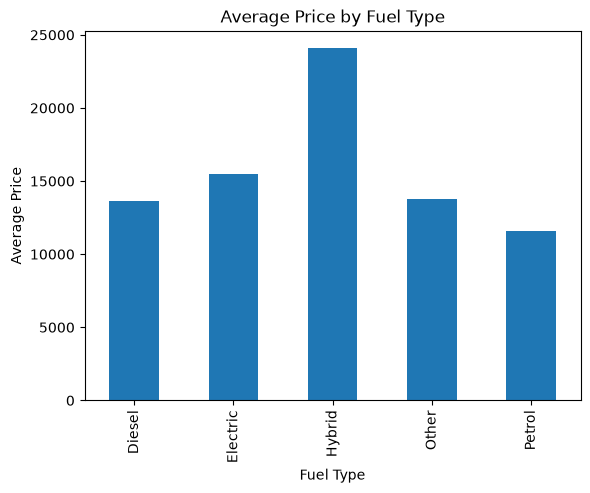

In [28]:
#Average price by fuel type
df.groupby('fuelType')['price'].mean().plot(kind='bar')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price')
plt.title('Average Price by Fuel Type')
plt.show()

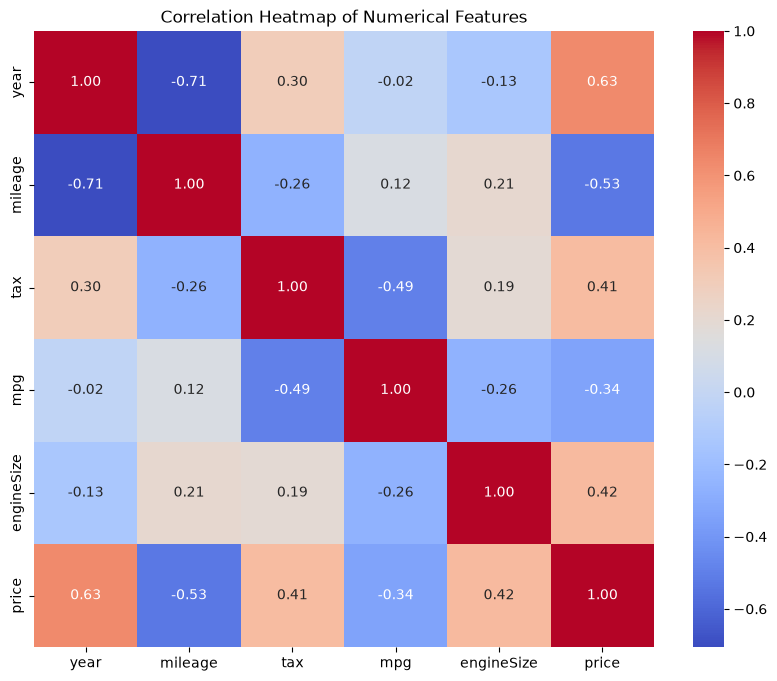

In [29]:
# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [30]:
#After analysing the data i have found some more anomalies
# 1. there are 42 rows with engine size 0
# 2. one car is manufactured in 2060 which is impossible

In [31]:
df=df[df['engineSize']!=0]


In [32]:
(df['engineSize']==0).sum()

np.int64(0)

In [33]:
df[df['year']>2020]

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
6217,Fiesta,2060,Automatic,54807,Petrol,205,42.8,1.4,6495


In [34]:
df=df[df['year']!=2060]

In [35]:
df[df['year']>2020]

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price


In [36]:
# i have checked and cleaned all my data i am checking rows and columns before starting preprocessing
df.shape

(14227, 9)

In [37]:
# Starting data preprocessing

In [38]:
# Separating the input features and target variable(price)
X=df.drop('price',axis=1)
y=df['price']

In [39]:
X.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Grand C-MAX,2015,Manual,58199,Diesel,30,64.2,1.5
1,Grand C-MAX,2011,Manual,73780,Petrol,200,40.9,1.6
2,Fiesta,2016,Manual,17050,Petrol,125,54.3,1.2
3,Focus,2018,Manual,19653,Petrol,145,41.5,2.0
4,Fiesta,2016,Manual,32268,Petrol,0,65.7,1.0


In [40]:
y.head()

0     9499
1     5485
2     8600
3    17989
4     8105
Name: price, dtype: int64

In [41]:
#Identifying numerical and categorical columns
numerical_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
categorical_features = ['model', 'transmission', 'fuelType']


In [42]:
#Train\Test split (we will use 80/20 split)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
X_train.shape, X_test.shape

((11381, 8), (2846, 8))

In [44]:
#Preprocess categorical data
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [45]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [46]:
X_train_processed.shape

(11381, 35)

In [47]:
X_test_processed.shape

(2846, 35)

In [48]:
from sklearn.linear_model import LinearRegression

In [49]:
model = LinearRegression()

In [50]:
model.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](35,)","[-2075.23,-1584.6 , -253.3 ,..., -2.09, -55.78, 4630.58]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.558e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,35


In [51]:
y_pred = model.predict(X_test_processed)

In [52]:
y_pred[:10]

array([13478.3497607 ,  8759.10518787, 12835.56954836, 10357.37821325,
       13357.84178235,  7486.748995  , 15076.52537183, 13379.6710262 ,
       17112.26058691,  7631.26298633])

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [54]:
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

In [55]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1419.7289556942146
RMSE: 1900.6613905945185
R²: 0.8240361852166413


In [56]:
from sklearn.ensemble import RandomForestRegressor

In [57]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [58]:
rf_model.fit(X_train_processed, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [59]:
rf_pred = rf_model.predict(X_test_processed)

In [60]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 879.6265758792624
Random Forest RMSE: 1230.6970181510974
Random Forest R²: 0.926223820768489


In [61]:
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 879.6265758792624
RMSE: 1230.6970181510974
R²: 0.926223820768489


In [62]:
from sklearn.ensemble import GradientBoostingRegressor

In [63]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [64]:
gb_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [65]:
gb_pred = gb_model.predict(X_test_processed)

In [66]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = mean_squared_error(y_test, gb_pred) ** 0.5
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R²:", gb_r2)

Gradient Boosting MAE: 946.917151342794
Gradient Boosting RMSE: 1274.669014345963
Gradient Boosting R²: 0.9208576902707806


In [67]:
errors = abs(y_test - rf_pred)

error_analysis = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': rf_pred,
    'Absolute Error': errors.values
})

error_analysis.sort_values(
    'Absolute Error',
    ascending=False
).head(10)

,Actual Price,Predicted Price,Absolute Error
1261,35000,25506.47,9493.53
2064,25000,33936.41,8936.41
2230,29000,37454.11,8454.11
1592,29998,36832.10,6834.10
2434,48000,42208.38,5791.62
2773,14199,19474.08,5275.08
2345,16495,11221.19,5273.81
1694,15000,9756.35,5243.65
2771,24990,20037.29,4952.71
1320,16475,21272.89,4797.89


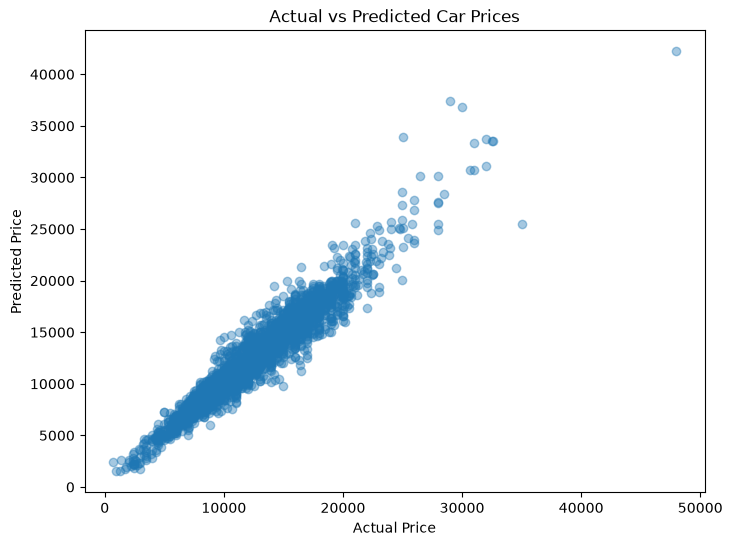

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.4)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

In [69]:
worst_indices = errors.sort_values(ascending=False).head(10).index
df.loc[worst_indices]

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
2080,S-MAX,2019,Automatic,3450,Diesel,145,51.4,2.0,35000
449,Mustang,2018,Manual,21632,Petrol,145,35.3,2.3,25000
3212,Mustang,2018,Automatic,11475,Petrol,145,28.8,2.3,29000
1816,Mustang,2018,Manual,20847,Petrol,145,20.9,5.0,29998
3621,Mustang,2020,Manual,50,Petrol,145,23.9,5.0,48000
10795,Focus,2018,Manual,13883,Petrol,145,58.9,1.0,14199
4952,Focus,2018,Manual,24344,Petrol,145,60.1,1.0,16495
14025,Fiesta,2018,Manual,22104,Petrol,150,65.7,1.0,15000
8894,Kuga,2019,Manual,3533,Petrol,145,35.3,1.5,24990
11812,Galaxy,2018,Manual,8346,Diesel,145,56.5,2.0,16475


In [70]:
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_processed, y_train)

y_pred_tuned = rf_tuned.predict(X_test_processed)

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = mean_squared_error(y_test, y_pred_tuned) ** 0.5
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Tuned Random Forest Results:
MAE: 877.8569436617623
RMSE: 1219.112358098887
R²: 0.9276062071599148


In [72]:
print(rf_tuned.predict(X_test_processed[:5]))

[12220.65849206  8474.58       13726.31333333 10160.02
 12658.68333333]


In [73]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_tuned
})

comparison.head(10)

,Actual Price,Predicted Price
0,14789,12220.658492
1,9681,8474.580000
2,11700,13726.313333
3,9995,10160.020000
4,12000,12658.683333
5,7495,6413.966667
6,16991,14949.690000
7,8688,9646.846667
8,19995,16593.226667
9,7495,8013.376667


In [74]:
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

In [75]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['model','year','transmission',...,'tax','mpg','engineSize']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the ou

In [76]:
final_predictions = final_model.predict(X_test)

In [77]:
final_mae = mean_absolute_error(y_test, final_predictions)

final_rmse = mean_squared_error(y_test, final_predictions) ** 0.5

final_r2 = r2_score(y_test, final_predictions)

print("Final Model Results:")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R²:", final_r2)

Final Model Results:
MAE: 877.8569436617623
RMSE: 1219.112358098887
R²: 0.9276062071599148


In [78]:
import joblib

In [79]:
joblib.dump(final_model, 'car_price_model.pkl')

['car_price_model.pkl']

In [80]:
import os

os.path.exists('car_price_model.pkl')

True

In [81]:
loaded_model = joblib.load('car_price_model.pkl')

In [82]:
new_car = pd.DataFrame({
    'model': ['Fiesta'],
    'year': [2018],
    'transmission': ['Manual'],
    'mileage': [30000],
    'fuelType': ['Petrol'],
    'tax': [145],
    'mpg': [50.0],
    'engineSize': [1.0]
})

In [83]:
prediction = loaded_model.predict(new_car)

print("Predicted Price:", prediction[0])

Predicted Price: 12526.321111111112


In [84]:
print(df['model'].unique())
print(df['transmission'].unique())
print(df['fuelType'].unique())

<ArrowStringArray>
[          ' Grand C-MAX',                ' Fiesta',                 ' Focus',
                  ' Edge',                 ' C-MAX',                   ' Ka+',
                    ' KA',                  ' Kuga',                ' Galaxy',
              ' EcoSport',                ' Mondeo',                 ' S-MAX',
       ' Tourneo Connect',               ' Mustang',                  ' Puma',
                 ' B-MAX',              ' Streetka', ' Grand Tourneo Connect',
                ' Fusion',                ' Ranger',        ' Tourneo Custom',
       ' Transit Tourneo',                ' Escort',                  'Focus']
Length: 24, dtype: str
<ArrowStringArray>
['Manual', 'Semi-Auto', 'Automatic']
Length: 3, dtype: str
<ArrowStringArray>
['Diesel', 'Petrol', 'Hybrid', 'Electric', 'Other']
Length: 5, dtype: str
